## Altimetría satelital aplicada a lagos someros con SWOT

### Caso de estudio: Lago Poopó, Bolivia

---

En este ejercicio utilizaremos observaciones de la misión
**Surface Water and Ocean Topography (SWOT)** para estudiar la dinámica
reciente del Lago Poopó.

SWOT permite observar simultáneamente dos características particularmente
interesantes de los cuerpos de agua:

- la **elevación de la superficie del agua**;
- la **extensión superficial observada**.

El Lago Poopó constituye un caso especialmente interesante porque es un
sistema muy somero y altamente variable.

La pregunta principal del ejercicio será:

> **¿Qué podemos aprender sobre la dinámica de un lago somero combinando
> observaciones satelitales de elevación, superficie y calidad de los datos?**

Durante el ejercicio trabajaremos con el producto oficial:

`SWOT_L2_HR_LakeSP_prior_D`

y utilizaremos **Hydrocron**, un servicio de NASA PO.DAAC que facilita
la construcción de series temporales a partir de los productos
hidrológicos de SWOT.

# 0. Objetivos del ejercicio

Al finalizar este ejercicio podrás:

1. Comprender de forma general cómo SWOT observa aguas continentales.

2. Reconocer algunos de los principales productos hidrológicos de SWOT.

3. Buscar y descargar un producto SWOT desde NASA Earthdata.

4. Explorar un archivo `LakeSP` en QGIS.

5. Identificar un lago en la SWOT Prior Lake Database.

6. Consultar una serie temporal SWOT mediante Hydrocron.

7. Interpretar variables como:

   - `wse`;
   - `wse_u`;
   - `area_total`;
   - `area_tot_u`;
   - `pass_id`;
   - `quality_f`;
   - `partial_f`.

8. Analizar el efecto de las diferentes pasadas orbitales.

9. Aplicar un control de calidad sencillo.

10. Explorar la relación entre elevación y extensión superficial
    en un lago somero.

# 1. ¿Qué es SWOT?

**SWOT** significa:

**Surface Water and Ocean Topography**

Es una misión satelital desarrollada conjuntamente por NASA y CNES,
con contribuciones de las agencias espaciales de Canadá y Reino Unido.

La misión fue lanzada en diciembre de 2022.

Uno de sus principales objetivos es observar cómo cambia el agua
superficial de la Tierra.

SWOT estudia:

- océanos;
- lagos;
- embalses;
- ríos;
- humedales.

Para aguas continentales, una de sus principales innovaciones es que
permite obtener información espacial sobre la superficie del agua,
en lugar de medir solamente a lo largo de una línea de nadir como ocurre
con la altimetría satelital convencional.

## KaRIn: el instrumento principal

El principal instrumento de SWOT es:

**Ka-band Radar Interferometer (KaRIn)**

KaRIn utiliza dos antenas separadas por un brazo de aproximadamente
10 metros.

Las dos observaciones permiten utilizar interferometría radar para
estimar la elevación de la superficie.

A diferencia de un altímetro convencional, SWOT observa una franja
o **swath** a ambos lados de la trayectoria del satélite.

Esto permite producir mapas bidimensionales de las aguas superficiales.

## Ciclo orbital

Durante la fase científica, SWOT sigue una órbita con un ciclo de
repetición de aproximadamente:

**21 días**

Esto no significa necesariamente que todos los lagos tengan una
observación válida exactamente cada 21 días.

La frecuencia real depende de:

- latitud;
- geometría orbital;
- posición dentro del swath;
- disponibilidad de observaciones válidas.

Un lago también puede ser observado por diferentes pasadas
(`pass_id`) dentro del mismo ciclo.

# 2. Principales productos hidrológicos de SWOT

SWOT produce datos con diferentes niveles de procesamiento.

Para este curso es suficiente reconocer algunos de los productos
principales:

| Producto | Tipo de información | Formato |
|---|---|---|
| PIXC | Nube de píxeles de agua | NetCDF |
| PIXCVec | Información vectorial asociada a PIXC | NetCDF |
| Raster | Variables hidrológicas en una grilla | NetCDF |
| RiverSP | Variables agregadas para ríos | Shapefile |
| LakeSP | Variables agregadas para lagos | Shapefile |
| LakeAvg | Información de lagos agregada por ciclo | Shapefile |

Los productos PIXC contienen información mucho más detallada.

Los productos RiverSP y LakeSP están más procesados y son
considerablemente más fáciles de utilizar para aplicaciones
hidrológicas introductorias.

En este ejercicio utilizaremos:

**LakeSP**

# 3. SWOT Level-2 Lake Single-Pass Vector Product

El producto:

`SWOT_L2_HR_LakeSP`

resume las observaciones de SWOT para cuerpos de agua identificados
durante una pasada del satélite.

Cada granule representa una determinada combinación de:

- ciclo orbital;
- pasada;
- continente;
- período de observación.

El producto contiene, entre otras variables:

- elevación superficial del agua;
- incertidumbre de la elevación;
- área superficial;
- incertidumbre del área;
- indicadores de calidad;
- información sobre cobertura parcial.

El producto se distribuye como **ESRI Shapefile**.

## Tres tipos de objetos dentro de LakeSP

El producto LakeSP distingue diferentes formas de organizar los
cuerpos de agua.

### Obs

Representa cuerpos de agua efectivamente observados durante la pasada.

### Prior

Organiza las observaciones utilizando los lagos previamente definidos
en la **Prior Lake Database (PLD)**.

### Unassigned

Incluye objetos de agua detectados por SWOT que no pudieron asociarse
a un lago de la PLD o a la base de datos de ríos.

---

En este ejercicio utilizaremos:

`SWOT_L2_HR_LakeSP_prior_D`

porque queremos seguir el **mismo lago a través del tiempo**.

# 4. Explorando un archivo SWOT original

Antes de construir una serie temporal vamos a observar cómo se
distribuyen originalmente los datos.

## Requisito

Para esta actividad necesitas una cuenta gratuita de:

**NASA Earthdata Login**

---

## Paso 1

Abre **NASA Earthdata Search**.

Busca exactamente el producto:

`SWOT_L2_HR_LakeSP_prior_D`

Asegúrate de seleccionar:

**SWOT Level 2 Lake Single-Pass Vector Prior Data Product, Version D**

---

## Paso 2

Utiliza la herramienta de búsqueda espacial y dibuja un rectángulo
alrededor del Lago Poopó.

Como referencia, el lago se encuentra aproximadamente alrededor de:

- Latitud: -18.8°
- Longitud: -67.0°

---

## Paso 3

Para reducir el número de resultados puedes utilizar, por ejemplo,
el período:

**1 julio 2025 – 31 julio 2025**

---

## Paso 4

Selecciona uno de los granules encontrados y descarga el archivo.

Los datos LakeSP se distribuyen en formato:

**ESRI Shapefile**

## 4.1 Abrir el archivo en QGIS

Una vez descargado el archivo:

1. Descomprímelo si está comprimido.

2. Abre QGIS.

3. Selecciona:

   **Capa → Añadir capa → Añadir capa vectorial**

4. Selecciona el archivo `.shp`.

5. Añade la capa al mapa.

6. Abre la **tabla de atributos**.

---

### Busca algunas de estas variables

- `lake_id`
- `lake_name`
- `wse`
- `wse_u`
- `wse_std`
- `area_total`
- `area_tot_u`
- `quality_f`
- `partial_f`

---

### Busca el Lago Poopó

En la tabla de atributos utiliza el campo:

`lake_id`

y busca el identificador correspondiente al Lago Poopó.

Más adelante encontraremos ese identificador directamente en la
Prior Lake Database.

---

### Preguntas

1. ¿Cuántos lagos contiene el archivo?

2. ¿El archivo contiene solamente Lago Poopó?

3. ¿Qué valor de WSE aparece para Poopó?

4. ¿Qué área superficial aparece?

5. ¿Qué valores tienen `quality_f` y `partial_f`?

6. ¿Qué ciclo y pasada representa el archivo?

## 4.2 ¿Cómo construiríamos una serie temporal manualmente?

El archivo que acabamos de abrir representa solamente una parte
del archivo histórico de SWOT.

Para construir manualmente una serie temporal tendríamos que:

1. identificar todos los granules que intersectan Lago Poopó;

2. descargar cada archivo;

3. abrir cada shapefile;

4. buscar el mismo `lake_id`;

5. extraer las mismas variables;

6. recuperar la fecha, ciclo y pasada;

7. combinar todas las observaciones;

8. ordenar los registros temporalmente.

Para unos pocos archivos esto es posible.

Pero para analizar varios años, muchos lagos o muchas variables
el procedimiento se vuelve poco eficiente.

Aquí es donde aparece **Hydrocron**.

# 5. ¿Qué es Hydrocron?

**Hydrocron** es una API desarrollada por NASA PO.DAAC para facilitar
el acceso a las series temporales de los productos hidrológicos de SWOT.

Hydrocron NO vuelve a calcular:

- WSE;
- superficie;
- incertidumbres;
- quality flags.

Estas variables ya fueron calculadas durante el procesamiento
científico de SWOT.

Hydrocron se encarga principalmente de:

- localizar los archivos correspondientes;
- identificar un feature específico;
- reunir observaciones de múltiples fechas;
- seleccionar las variables solicitadas;
- devolverlas en un formato sencillo (CSV).

# 6. Buscar el Lago Poopó en la Prior Lake Database

Hydrocron no busca los lagos principalmente por nombre.

Para los productos `PriorLake` utilizaremos el identificador:

`lake_id`

Este identificador proviene de la:

**SWOT Prior Lake Database (PLD)**

---

## Actividad

Abre el visor de la Prior Lake Database:
https://www.arcgis.com/apps/mapviewer/index.html?url=https%3A%2F%2Farcgis.cuahsi.org%2Farcgis%2Frest%2Fservices%2FSWOT%2FSWOT_pld_v202%2FFeatureServer%2F0&utm

1. Navega hasta Bolivia.

2. Localiza el Lago Poopó.

3. Haz clic sobre el polígono.

4. Busca el atributo:

   `lake_id_Double`

5. Copia el número.

---

### Importante

Si el visor muestra algo como:

`6,640,025,173.00`

debes convertirlo a:

`6640025173`

Es decir:

- eliminar separadores de miles;
- eliminar `.00`;
- conservar los diez dígitos.

Guarda también, si aparecen, los valores:

- `cycle_flag_nom`
- `pass_full_nom`
- `pass_part_nom`

Los utilizaremos para interpretar posteriormente la geometría orbital.

In [1]:
# ============================================================
# Identificador del lago
# ============================================================

# Reemplaza el texto con el lake_id que encontraste
# en la Prior Lake Database.

LAKE_ID = "6640025173"

print("Lake ID seleccionado:", LAKE_ID)

Lake ID seleccionado: 6640025173


# 7. Preparación del entorno

A diferencia de los ejercicios anteriores, aquí no necesitamos
Google Earth Engine.

Los datos se obtendrán directamente mediante una consulta web
a Hydrocron.

Utilizaremos:

- `requests`: realizar la consulta;
- `pandas`: organizar los datos;
- `numpy`: operaciones numéricas;
- `matplotlib`: gráficos.

In [2]:
# ============================================================
# Importar librerías
# ============================================================

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from io import StringIO
from datetime import datetime, timezone

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# 8. Definir nuestra consulta

Analizaremos la fase científica de SWOT.

Comenzaremos en:

**agosto de 2023**

y solicitaremos observaciones hasta la fecha actual.

Pediremos solamente un conjunto pequeño de variables.

## Variables hidrológicas

- `wse`: Water Surface Elevation
- `wse_u`: incertidumbre de WSE
- `wse_std`: dispersión de las elevaciones utilizadas
- `area_total`: superficie estimada
- `area_tot_u`: incertidumbre de superficie

## Información orbital

- `cycle_id`
- `pass_id`

## Control de calidad

- `quality_f`
- `partial_f`
- `dark_frac`
- `xovr_cal_q`

In [3]:
# ============================================================
# Período de análisis
# ============================================================

START_TIME = "2023-08-01T00:00:00Z"

END_TIME = datetime.now(
    timezone.utc
).strftime(
    "%Y-%m-%dT%H:%M:%SZ"
)

print("Inicio:", START_TIME)
print("Fin:", END_TIME)

Inicio: 2023-08-01T00:00:00Z
Fin: 2026-10-01T03:25:50Z


In [4]:
# ============================================================
# Variables solicitadas
# ============================================================

FIELDS = (
    "lake_id,"
    "lake_name,"
    "time_str,"
    "wse,"
    "wse_u,"
    "wse_std,"
    "area_total,"
    "area_tot_u,"
    "quality_f,"
    "partial_f,"
    "dark_frac,"
    "xovr_cal_q,"
    "cycle_id,"
    "pass_id"
)

print(FIELDS)

lake_id,lake_name,time_str,wse,wse_u,wse_std,area_total,area_tot_u,quality_f,partial_f,dark_frac,xovr_cal_q,cycle_id,pass_id


# 9. Consulta a Hydrocron

Ahora solicitaremos a Hydrocron:

> todas las observaciones LakeSP Prior del Lago Poopó durante
> el período seleccionado.

El parámetro más importante es:

`feature_id = LAKE_ID`

Por eso el identificador que encontramos en la PLD es fundamental.

Solicitaremos específicamente:

`SWOT_L2_HR_LakeSP_prior_D`

es decir, la versión D del producto LakeSP Prior.

In [5]:
# ============================================================
# Endpoint de Hydrocron
# ============================================================

HYDROCRON_URL = (
    "https://soto.podaac.earthdatacloud.nasa.gov/"
    "hydrocron/v1/timeseries"
)

In [6]:
# ============================================================
# Preparar la consulta
# ============================================================

params = {

    "feature": "PriorLake",

    "feature_id": LAKE_ID,

    "start_time": START_TIME,

    "end_time": END_TIME,

    "collection_name":
        "SWOT_L2_HR_LakeSP_prior_D",

    "output": "csv",

    "fields": FIELDS
}

In [7]:
# ============================================================
# Ejecutar la consulta
# ============================================================

response = requests.get(
    HYDROCRON_URL,
    params=params,
    timeout=120
)

print(
    "HTTP status:",
    response.status_code
)

response.raise_for_status()

print("Consulta realizada correctamente.")

HTTP status: 200
Consulta realizada correctamente.


In [8]:
# ============================================================
# Revisar respuesta Hydrocron
# ============================================================

hydrocron_response = response.json()

print(
    "Número de registros encontrados:",
    hydrocron_response.get("hits")
)

Número de registros encontrados: 215


In [9]:
# ============================================================
# Extraer el CSV de la respuesta
# ============================================================

csv_text = (
    hydrocron_response[
        "results"
    ][
        "csv"
    ]
)

print(
    csv_text[:500]
)

lake_id,lake_name,time_str,wse,wse_u,wse_std,area_total,area_tot_u,quality_f,partial_f,dark_frac,xovr_cal_q,cycle_id,pass_id,wse_units,wse_u_units,wse_std_units,area_total_units,area_tot_u_units,dark_frac_units
6640025173,POOPO;LAGO POOP,2023-08-02T20:45:46Z,3685.98,0.001,0.338,1274.626578,6.226621,1,0,0.782927,0,001,354,m,m,m,km^2,km^2,1
6640025173,POOPO;LAGO POOP,2023-08-02T20:45:46Z,3685.98,0.001,0.338,1274.626578,6.226621,1,0,0.782927,0,001,354,m,m,m,km^2,km^2,1
6640025173,POOPO;LAGO POOP,no


In [10]:
# ============================================================
# Convertir la respuesta a Pandas
# ============================================================

df_raw = pd.read_csv(
    StringIO(csv_text),
    dtype={
        "lake_id": str
    }
)

print(
    "Número de registros:",
    len(df_raw)
)

print(
    "Número de columnas:",
    len(df_raw.columns)
)

display(
    df_raw.head()
)

Número de registros: 215
Número de columnas: 20


,lake_id,lake_name,time_str,wse,wse_u,wse_std,area_total,area_tot_u,quality_f,partial_f,dark_frac,xovr_cal_q,cycle_id,pass_id,wse_units,wse_u_units,wse_std_units,area_total_units,area_tot_u_units,dark_frac_units
0,6640025173,POOPO;LAGO POOP,2023-08-02T20:45:46Z,3.685980e+03,1.000000e-03,3.380000e-01,1.274627e+03,6.226621e+00,1,0,7.829270e-01,0,1,354,m,m,m,km^2,km^2,1
1,6640025173,POOPO;LAGO POOP,2023-08-02T20:45:46Z,3.685980e+03,1.000000e-03,3.380000e-01,1.274627e+03,6.226621e+00,1,0,7.829270e-01,0,1,354,m,m,m,km^2,km^2,1
2,6640025173,POOPO;LAGO POOP,no_data,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,-999,-999,-1.000000e+12,-999,1,451,m,m,m,km^2,km^2,1
3,6640025173,POOPO;LAGO POOP,no_data,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,-999,-999,-1.000000e+12,-999,1,451,m,m,m,km^2,km^2,1
4,6640025173,POOPO;LAGO POOP,2023-08-23T17:30:48Z,3.685822e+03,1.000000e-03,3.470000e-01,7.046700e+02,4.041079e+00,1,1,7.686530e-01,0,2,354,m,m,m,km^2,km^2,1


# 11. Revisar las fechas

Una pasada del satélite sobre la región no implica necesariamente que
se produzca una observación válida del lago.

Por esta razón revisaremos primero `time_str`.

Convertiremos esta columna a una fecha de Pandas.

Cuando no exista una fecha válida utilizaremos `NaT`
(Not a Time).

In [11]:
# ============================================================
# Convertir fechas
# ============================================================

df_raw["date"] = pd.to_datetime(
    df_raw["time_str"],
    errors="coerce",
    utc=True
)

print(
    "Registros descargados:",
    len(df_raw)
)

print(
    "Observaciones con fecha válida:",
    df_raw["date"].notna().sum()
)

print(
    "Registros sin fecha válida:",
    df_raw["date"].isna().sum()
)

Registros descargados: 215
Observaciones con fecha válida: 143
Registros sin fecha válida: 72


### Pregunta

> ¿Por qué el número de registros descargados puede ser mayor que
> el número de observaciones válidas?

Una pasada orbital puede estar asociada espacialmente con el lago,
pero las condiciones de la observación pueden impedir que se genere
una medición válida.

Por eso es importante diferenciar:

**pasada del satélite**

de

**observación hidrológica válida**.

In [12]:
# ============================================================
# Conservar observaciones con fecha válida
# ============================================================

df = (
    df_raw[
        df_raw["date"].notna()
    ]
    .copy()
    .sort_values("date")
    .reset_index(drop=True)
)

print(
    "Observaciones de trabajo:",
    len(df)
)

Observaciones de trabajo: 143


In [13]:
# ============================================================
# Convertir variables a formato numérico
# ============================================================

numeric_columns = [
    "wse",
    "wse_u",
    "wse_std",
    "area_total",
    "area_tot_u",
    "quality_f",
    "partial_f",
    "dark_frac",
    "xovr_cal_q",
    "cycle_id",
    "pass_id"
]

for column in numeric_columns:

    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

print("Variables numéricas preparadas.")

Variables numéricas preparadas.


In [14]:
# ============================================================
# Eliminar únicamente valores de relleno extremos
# ============================================================

measurement_columns = [
    "wse",
    "wse_u",
    "wse_std",
    "area_total",
    "area_tot_u",
    "dark_frac"
]

for column in measurement_columns:

    df.loc[
        df[column] < -1e10,
        column
    ] = np.nan

In [15]:
# ============================================================
# Explorar la tabla
# ============================================================

columns_to_show = [
    "date",
    "cycle_id",
    "pass_id",
    "wse",
    "wse_u",
    "area_total",
    "area_tot_u",
    "quality_f",
    "partial_f"
]

display(
    df[
        columns_to_show
    ].head(15)
)

,date,cycle_id,pass_id,wse,wse_u,area_total,area_tot_u,quality_f,partial_f
0,2023-08-02 20:45:46+00:00,1,354,3685.980,0.001,1274.626578,6.226621,1,0
1,2023-08-02 20:45:46+00:00,1,354,3685.980,0.001,1274.626578,6.226621,1,0
2,2023-08-23 17:30:48+00:00,2,354,3685.822,0.001,704.669954,4.041079,1,1
3,2023-09-13 14:15:55+00:00,3,354,3685.746,0.001,713.308885,3.150874,1,1
4,2023-10-04 11:00:59+00:00,4,354,3685.898,0.001,1247.557289,4.774955,1,0
5,2023-10-17 20:22:44+00:00,5,145,3685.800,0.002,1237.883458,1.507366,1,1
6,2023-10-25 07:46:03+00:00,5,354,3686.937,0.002,1557.900119,6.590989,1,0
7,2023-11-07 17:07:50+00:00,6,145,3686.419,0.005,1369.593777,2.760546,1,1
8,2023-11-15 04:31:08+00:00,6,354,3686.641,0.003,1487.131197,5.645656,1,0
9,2023-11-26 02:53:56+00:00,7,76,3686.272,0.059,0.689592,0.007868,1,0


### Observa la tabla

Antes de hacer cualquier gráfico identifica:

- las fechas;
- los diferentes `cycle_id`;
- los diferentes `pass_id`;
- el rango de WSE;
- el rango de área;
- los indicadores de calidad.

### Pregunta

> ¿Deberíamos asumir que todas las observaciones son igualmente
> confiables?

Todavía no aplicaremos ningún filtro.

Primero observaremos los datos tal como fueron obtenidos.

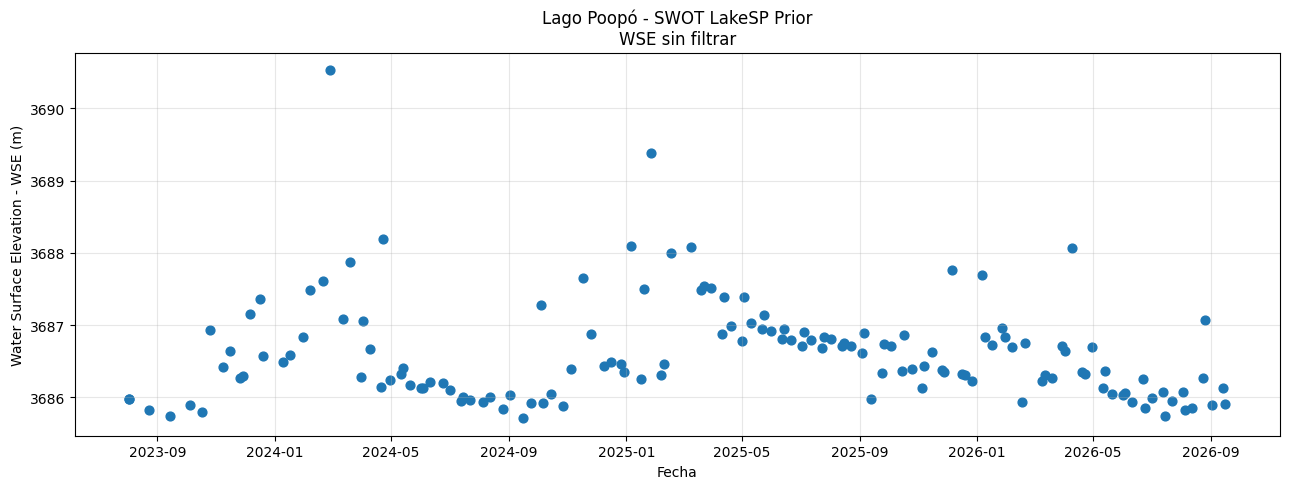

In [16]:
# ============================================================
# WSE sin filtrar
# ============================================================

plt.figure(figsize=(13, 5))

plt.scatter(
    df["date"],
    df["wse"],
    s=40
)

plt.xlabel("Fecha")
plt.ylabel("Water Surface Elevation - WSE (m)")

plt.title(
    "Lago Poopó - SWOT LakeSP Prior\n"
    "WSE sin filtrar"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observa la serie

1. ¿Existe una señal temporal coherente?

2. ¿Aparecen valores aislados?

3. ¿Cuál es aproximadamente el rango de elevaciones?

4. ¿Todos los puntos parecen físicamente razonables?

No eliminaremos puntos visualmente.

Utilizaremos la información de calidad incluida en el propio producto.

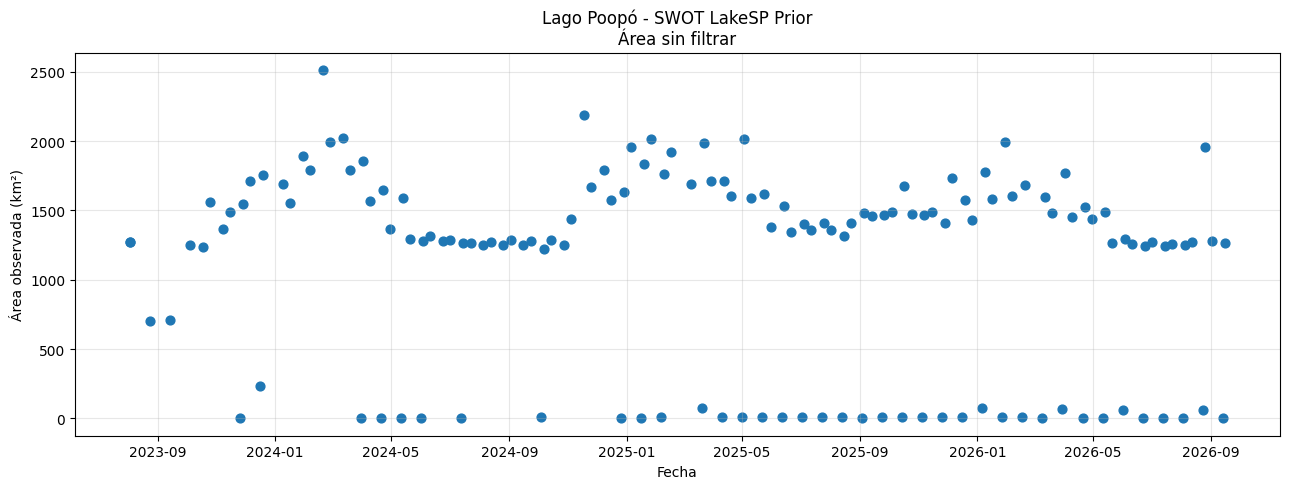

In [17]:
# ============================================================
# Área sin filtrar
# ============================================================

plt.figure(figsize=(13, 5))

plt.scatter(
    df["date"],
    df["area_total"],
    s=40
)

plt.xlabel("Fecha")
plt.ylabel("Área observada (km²)")

plt.title(
    "Lago Poopó - SWOT LakeSP Prior\n"
    "Área sin filtrar"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Algo extraño debería aparecer

Compara la serie de área con la serie de WSE.

### Preguntas

1. ¿Existen áreas extremadamente pequeñas?

2. ¿Significa necesariamente que el Lago Poopó desapareció?

3. ¿Por qué la serie de WSE parece más coherente que la de área?

Antes de interpretar esos puntos debemos entender la geometría
de las observaciones.

# 16. ¿Qué es `pass_id`?

SWOT observa el mismo lugar desde diferentes trayectorias orbitales.

El campo:

`pass_id`

identifica la pasada correspondiente a cada observación.

Para un lago grande, diferentes pasadas pueden intersectar
porciones diferentes del cuerpo de agua.

Esto tiene consecuencias importantes para la estimación del área.

In [18]:
# ============================================================
# Pasadas disponibles
# ============================================================

print(
    "Pass IDs encontrados:"
)

print(
    sorted(
        df["pass_id"]
        .dropna()
        .astype(int)
        .unique()
    )
)

Pass IDs encontrados:
[np.int64(76), np.int64(145), np.int64(354)]


In [19]:
# ============================================================
# Resumen por pasada
# ============================================================

pass_summary = (
    df
    .groupby("pass_id")
    .agg(
        observations=("area_total", "count"),
        median_area=("area_total", "median"),
        min_area=("area_total", "min"),
        max_area=("area_total", "max"),
        median_wse=("wse", "median"),
        min_wse=("wse", "min"),
        max_wse=("wse", "max")
    )
    .round(2)
)

display(pass_summary)

,observations,median_area,min_area,max_area,median_wse,min_wse,max_wse
pass_id,,,,,,,
76,38,7.05,0.68,233.37,3686.34,3685.93,3687.69
145,51,1548.51,1223.37,2512.52,3686.46,3685.71,3688.19
354,54,1439.34,704.67,2013.62,3686.61,3685.75,3690.53


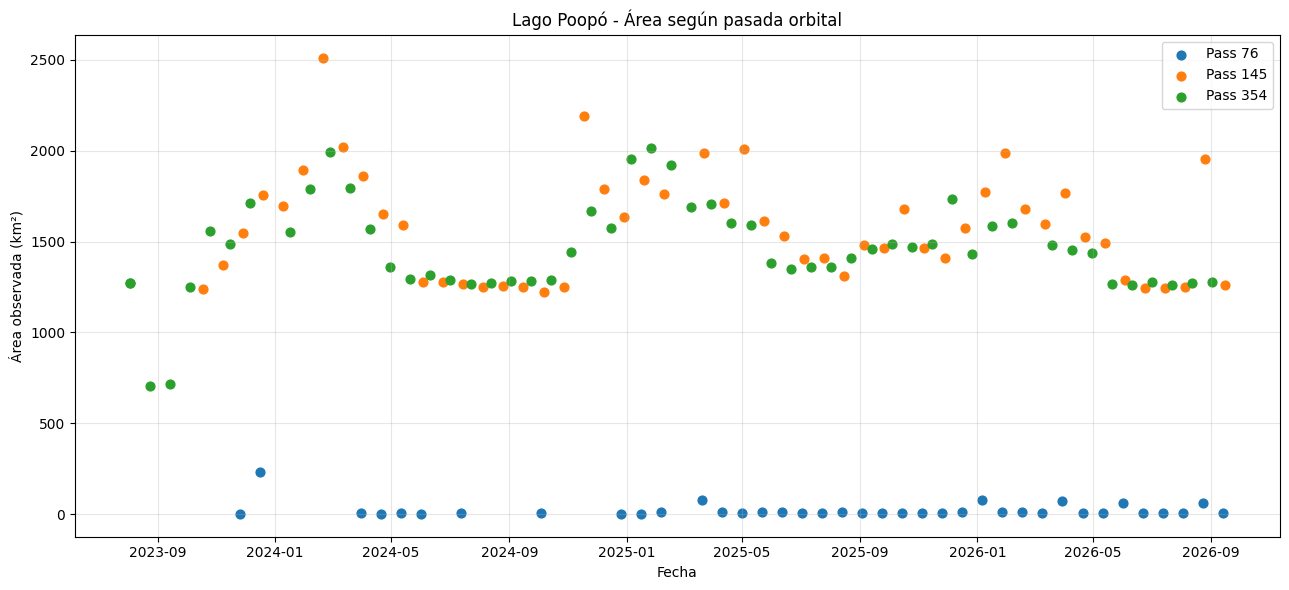

In [20]:
# ============================================================
# Área según pasada orbital
# ============================================================

plt.figure(figsize=(13, 6))

for pass_id in sorted(
    df["pass_id"].dropna().unique()
):

    subset = df[
        df["pass_id"] == pass_id
    ]

    plt.scatter(
        subset["date"],
        subset["area_total"],
        s=40,
        label=f"Pass {int(pass_id)}"
    )

plt.xlabel("Fecha")
plt.ylabel("Área observada (km²)")

plt.title(
    "Lago Poopó - Área según pasada orbital"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpreta el resultado

Ahora podemos volver a la pregunta:

> ¿Los valores extremadamente pequeños de área significan
> necesariamente que el lago estaba seco?

Compara los valores con `pass_id`.

### Preguntas

1. ¿Qué pasada produce las áreas más pequeñas?

2. ¿Las diferentes pasadas producen rangos comparables?

3. ¿Qué relación puede existir entre la geometría orbital y
   `area_total`?

---

### Concepto importante

Una pasada puede observar solo una parte de un lago.

Por tanto:

> `area_total` debe interpretarse teniendo en cuenta la geometría
> y cobertura de la observación.

Esto es especialmente importante en cuerpos de agua grandes y someros.

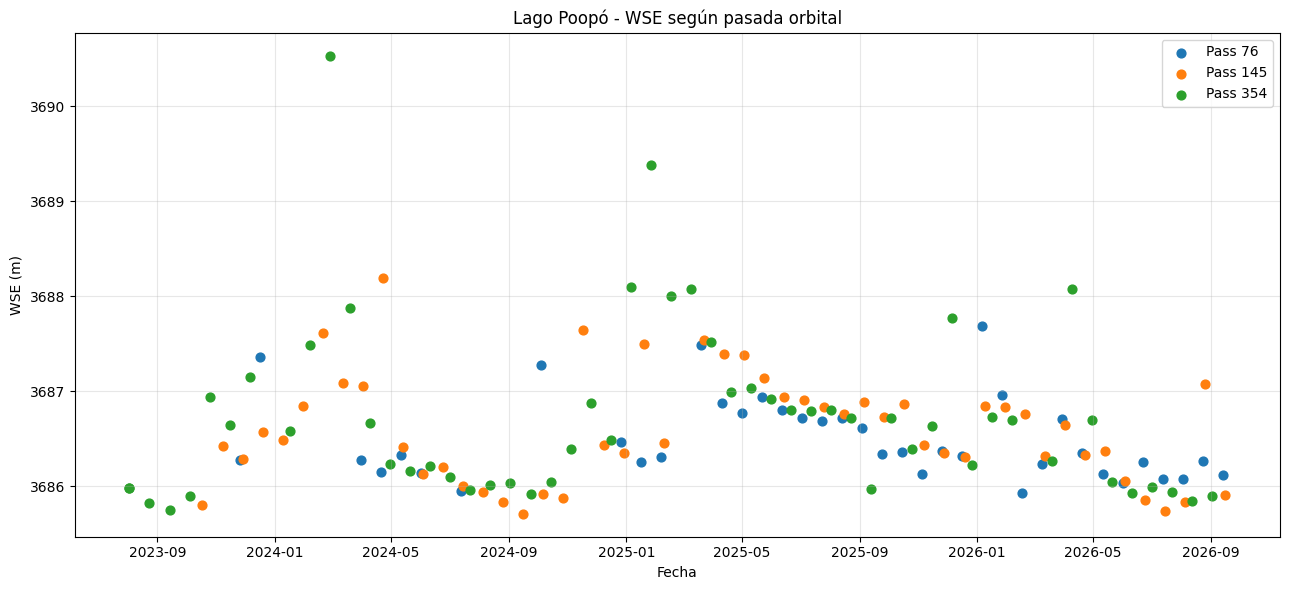

In [21]:
# ============================================================
# WSE según pasada orbital
# ============================================================

plt.figure(figsize=(13, 6))

for pass_id in sorted(
    df["pass_id"].dropna().unique()
):

    subset = df[
        df["pass_id"] == pass_id
    ]

    plt.scatter(
        subset["date"],
        subset["wse"],
        s=40,
        label=f"Pass {int(pass_id)}"
    )

plt.xlabel("Fecha")
plt.ylabel("WSE (m)")

plt.title(
    "Lago Poopó - WSE según pasada orbital"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Una diferencia fundamental

Compara este gráfico con el gráfico del área.

Una observación parcial puede ser problemática para estimar la
**superficie total** del lago.

Sin embargo, una parte del lago todavía puede proporcionar información
útil sobre la **elevación de la superficie del agua**, siempre que la
medición tenga calidad suficiente.

Por eso:

> los criterios de interpretación de WSE y área no tienen por qué ser
> exactamente los mismos.

# 18. Control de calidad

Los productos SWOT incluyen variables diseñadas específicamente para
evaluar la calidad de las observaciones.

En este ejercicio utilizaremos principalmente:

### `quality_f`

Indicador resumen de calidad de la observación.

Para mantener el taller sencillo utilizaremos:

`quality_f == 0`

como criterio de observación nominal o de buena calidad.

No intentaremos decodificar todos los posibles valores no cero.

---

### `partial_f`

Indica si la observación presenta cobertura parcial.

En términos generales:

- 0 → cubierta;
- 1 → parcialmente cubierta.

---

También descargamos:

- `dark_frac`;
- `xovr_cal_q`.

Los observaremos brevemente, pero no construiremos filtros complejos
con ellos.

In [22]:
# ============================================================
# Distribución de quality_f
# ============================================================

print("QUALITY_F")

print(
    df["quality_f"]
    .value_counts(dropna=False)
    .sort_index()
)

QUALITY_F
quality_f
0    43
1    93
2     4
3     3
Name: count, dtype: int64


In [23]:
# ============================================================
# Distribución de partial_f
# ============================================================

print("PARTIAL_F")

print(
    df["partial_f"]
    .value_counts(dropna=False)
    .sort_index()
)

PARTIAL_F
partial_f
0    64
1    79
Name: count, dtype: int64


In [24]:
# ============================================================
# Relación entre quality_f y partial_f
# ============================================================

quality_table = pd.crosstab(
    df["quality_f"],
    df["partial_f"],
    margins=True
)

display(quality_table)

partial_f,0,1,All
quality_f,,,
0,12,31,43
1,46,47,93
2,3,1,4
3,3,0,3
All,64,79,143


### Preguntas

1. ¿Qué proporción de las observaciones tiene `quality_f = 0`?

2. ¿Cuántas observaciones tienen `partial_f = 1`?

3. ¿Una observación puede tener buena calidad y ser parcial?

4. ¿Significan entonces `quality_f` y `partial_f` exactamente lo mismo?

No.

Una medición puede ser técnicamente adecuada y, al mismo tiempo,
representar solamente una parte del lago.

# 19. Filtrar la serie de elevación

Aplicaremos un criterio deliberadamente sencillo:

**conservar solamente observaciones con `quality_f = 0`**

Esto permitirá comparar:

- serie original;
- serie con control de calidad.

No utilizaremos todavía criterios estadísticos para eliminar outliers.

In [25]:
# ============================================================
# Filtrar observaciones nominales
# ============================================================

df_good = df[
    df["quality_f"] == 0
].copy()

print(
    "Observaciones antes del filtro:",
    len(df)
)

print(
    "Observaciones después del filtro:",
    len(df_good)
)

Observaciones antes del filtro: 143
Observaciones después del filtro: 43


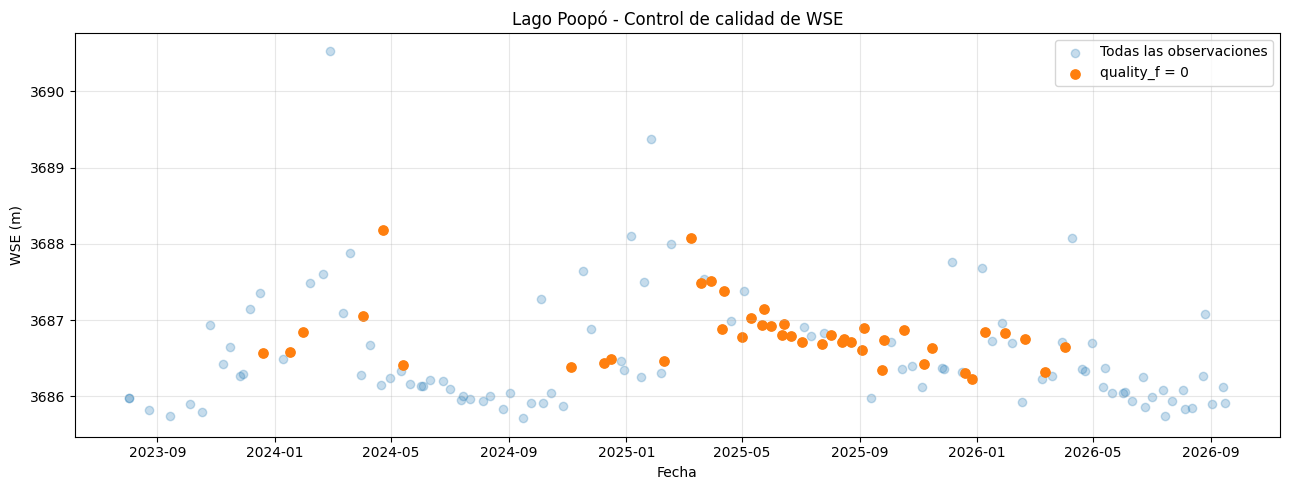

In [26]:
# ============================================================
# WSE filtrado
# ============================================================

plt.figure(figsize=(13, 5))

plt.scatter(
    df["date"],
    df["wse"],
    alpha=0.25,
    label="Todas las observaciones"
)

plt.scatter(
    df_good["date"],
    df_good["wse"],
    s=45,
    label="quality_f = 0"
)

plt.xlabel("Fecha")
plt.ylabel("WSE (m)")

plt.title(
    "Lago Poopó - Control de calidad de WSE"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Preguntas

1. ¿Desaparecieron algunos valores extremos?

2. ¿La serie temporal se vuelve más coherente?

3. ¿Se eliminaron muchas observaciones?

4. ¿Cuál es el costo de utilizar criterios de calidad más estrictos?

El control de calidad siempre implica un compromiso entre:

**cantidad de observaciones**

y

**confianza en las observaciones**.

# 20. Incertidumbre de WSE

SWOT no proporciona únicamente un valor de elevación.

También proporciona:

`wse_u`

que representa la incertidumbre asociada a la estimación de WSE.

Esto permite comunicar los resultados como:

\[
WSE \pm incertidumbre
\]

en lugar de tratar cada estimación como un valor exacto.

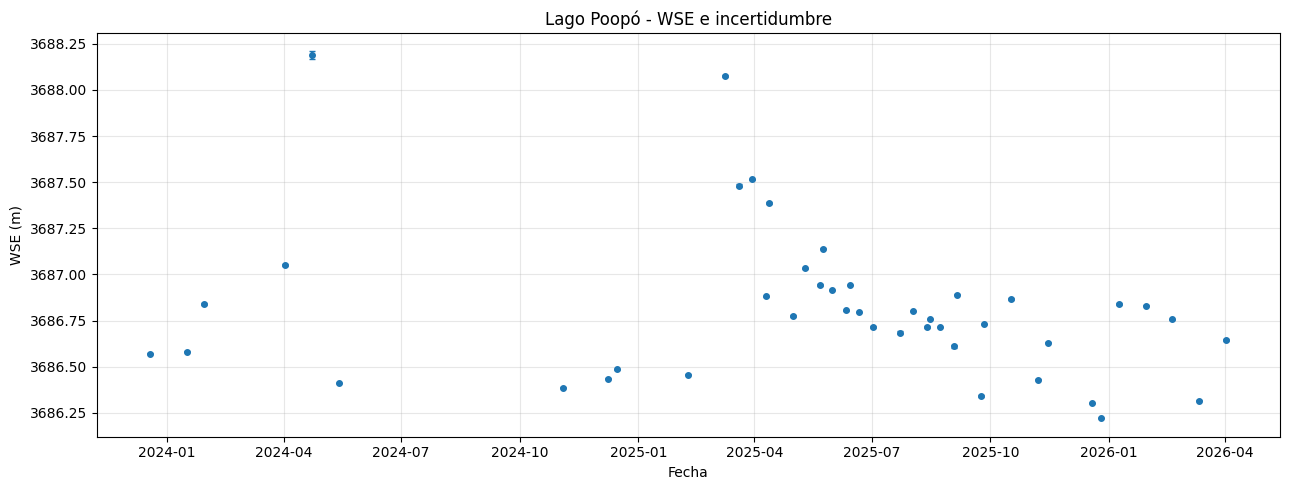

In [27]:
# ============================================================
# WSE con barras de incertidumbre
# ============================================================

plt.figure(figsize=(13, 5))

plt.errorbar(
    df_good["date"],
    df_good["wse"],
    yerr=df_good["wse_u"],
    fmt="o",
    markersize=4,
    capsize=2
)

plt.xlabel("Fecha")
plt.ylabel("WSE (m)")

plt.title(
    "Lago Poopó - WSE e incertidumbre"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Pregunta

> ¿Todas las observaciones tienen la misma incertidumbre?

¿Por qué es importante conservar `wse_u` junto con `wse`?

Una serie satelital no está compuesta únicamente por valores.

También debemos considerar la confianza asociada a cada medición.

# 21. Analizar superficie dentro de una misma pasada

La comparación anterior mostró que las diferentes pasadas pueden
observar proporciones muy distintas del Lago Poopó.

Por esta razón NO combinaremos indiscriminadamente todas las
observaciones de `area_total`.

Para explorar la relación entre área y elevación utilizaremos una sola
geometría orbital.

Para el caso del Lago Poopó utilizaremos:

**Pass 145**

Esto NO significa que la pasada observe necesariamente el lago completo.

El objetivo es mantener una geometría aproximadamente consistente
entre fechas.

In [28]:
# ============================================================
# Seleccionar una pasada
# ============================================================

SELECTED_PASS = 145

df_pass = df[
    (df["pass_id"] == SELECTED_PASS)
    &
    (df["quality_f"] == 0)
].copy()

print(
    "Observaciones seleccionadas:",
    len(df_pass)
)

Observaciones seleccionadas: 21


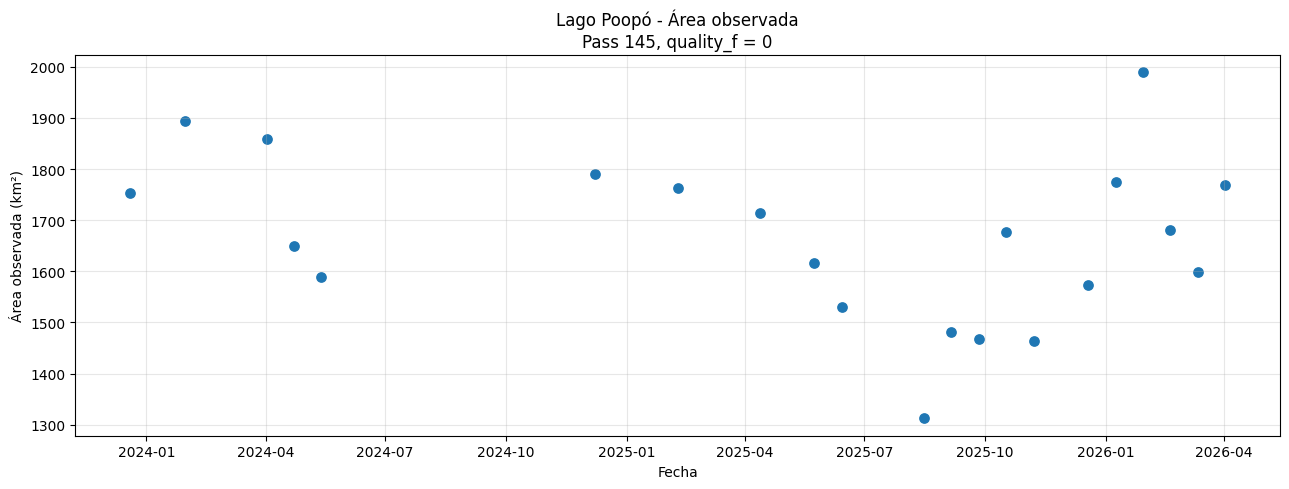

In [29]:
# ============================================================
# Serie de área para una misma pasada
# ============================================================

plt.figure(figsize=(13, 5))

plt.scatter(
    df_pass["date"],
    df_pass["area_total"],
    s=45
)

plt.xlabel("Fecha")
plt.ylabel("Área observada (km²)")

plt.title(
    f"Lago Poopó - Área observada\n"
    f"Pass {SELECTED_PASS}, quality_f = 0"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Importante

En esta sección NO interpretaremos `area_total` como una medición
perfecta del área completa del Lago Poopó.

Lo utilizamos para estudiar cambios observados bajo una
**geometría orbital consistente**.

Esta distinción es especialmente importante porque la PLD muestra que
Poopó puede ser observado de forma parcial por diferentes pasadas.

# 22. Relación entre elevación y superficie

Ahora combinaremos las dos variables principales:

- `wse`;
- `area_total`.

En un lago somero esperamos que cambios relativamente pequeños de nivel
puedan producir cambios importantes de superficie.

Esto ocurre porque pequeñas variaciones verticales pueden desplazar la
línea de costa grandes distancias sobre una topografía muy plana.

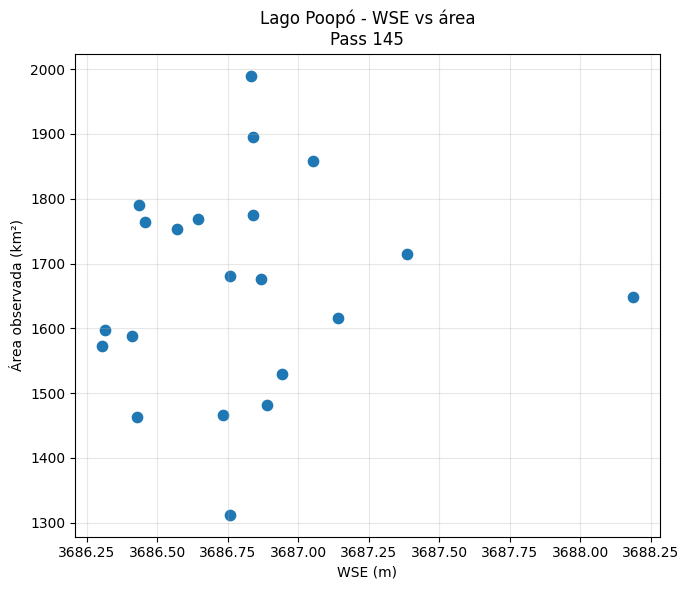

In [30]:
# ============================================================
# WSE vs área
# ============================================================

plot_data = df_pass[
    [
        "wse",
        "area_total"
    ]
].dropna()

plt.figure(figsize=(7, 6))

plt.scatter(
    plot_data["wse"],
    plot_data["area_total"],
    s=55
)

plt.xlabel("WSE (m)")
plt.ylabel("Área observada (km²)")

plt.title(
    f"Lago Poopó - WSE vs área\n"
    f"Pass {SELECTED_PASS}"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Preguntas

1. ¿Existe una relación entre WSE y área?

2. ¿El área aumenta cuando aumenta el nivel?

3. ¿La relación parece perfectamente lineal?

4. ¿Qué factores podrían introducir dispersión?

Considera:

- incertidumbre de la medición;
- geometría orbital;
- cobertura parcial;
- cambios en la forma del lago;
- clasificación de agua;
- vegetación o superficies complejas.

In [31]:
# ============================================================
# Rango observado de WSE y área
# ============================================================

wse_range = (
    plot_data["wse"].max()
    - plot_data["wse"].min()
)

area_range = (
    plot_data["area_total"].max()
    - plot_data["area_total"].min()
)

median_area = (
    plot_data["area_total"].median()
)

area_change_pct = (
    area_range
    / median_area
    * 100
)

print(
    f"Rango de WSE: "
    f"{wse_range:.2f} m"
)

print(
    f"Rango de área: "
    f"{area_range:.1f} km²"
)

print(
    f"Rango de área respecto a la mediana: "
    f"{area_change_pct:.1f} %"
)

Rango de WSE: 1.89 m
Rango de área: 677.6 km²
Rango de área respecto a la mediana: 40.4 %


## Interpretación

Compara ahora las dos magnitudes:

**cambio vertical**

frente a

**cambio horizontal de superficie**

En un lago profundo, una variación pequeña de nivel puede producir
un cambio relativamente pequeño en la línea de costa.

En un lago muy somero:

pequeño cambio de WSE

↓

gran desplazamiento de la costa

↓

gran cambio de superficie

Esta es una de las razones por las cuales combinar altimetría y
extensión superficial es particularmente interesante para estudiar
lagos someros.

# 24. Otros indicadores de calidad

SWOT contiene información adicional que puede utilizarse para realizar
un control de calidad más avanzado.

Dos ejemplos son:

### `dark_frac`

Fracción de la superficie asociada a condiciones de "dark water",
donde el retorno radar puede dificultar la detección.

### `xovr_cal_q`

Indicador relacionado con la calidad de la calibración crossover.

En este taller no construiremos filtros complejos con estas variables.

Simplemente observaremos su distribución.

In [32]:
# ============================================================
# Explorar indicadores adicionales
# ============================================================

print("XOVR_CAL_Q")

print(
    df["xovr_cal_q"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nDARK_FRAC")

display(
    df["dark_frac"]
    .describe()
)

XOVR_CAL_Q
xovr_cal_q
0    138
1      2
2      3
Name: count, dtype: int64

DARK_FRAC


,dark_frac
count,143.000000
mean,0.358597
std,0.289071
min,0.000000
25%,0.100594
50%,0.273998
75%,0.593689
max,0.991097


# 25. Interpretación conjunta

Durante este ejercicio seguimos el siguiente flujo:

**SWOT**

↓

**LakeSP Prior**

↓

**archivo Shapefile original**

↓

**Prior Lake Database**

↓

**lake_id**

↓

**Hydrocron**

↓

**serie temporal**

↓

**pass_id**

↓

**quality flags**

↓

**WSE filtrado**

↓

**área bajo una geometría consistente**

↓

**relación WSE–área**

---

## Pregunta 1

¿Por qué Hydrocron facilita el análisis respecto a descargar
manualmente todos los shapefiles?

---

## Pregunta 2

¿Por qué `pass_id` es particularmente importante para interpretar
el área superficial?

---

## Pregunta 3

¿Por qué una observación parcial podría seguir siendo útil para WSE?

---

## Pregunta 4

¿Qué diferencia existe entre:

`wse`

y

`wse_u`?

---

## Pregunta 5

¿Por qué no deberíamos eliminar puntos solamente porque
"se ven raros"?

---

## Pregunta 6

¿Qué nos enseña la relación WSE–área sobre el funcionamiento
de un lago somero?

# 26. Limitaciones

## 1. Cobertura orbital

SWOT no observa necesariamente todo el lago durante cada pasada.

Por eso `pass_id` y las condiciones de cobertura deben considerarse
al interpretar `area_total`.

---

## 2. Quality flags

Una medición satelital debe interpretarse junto con la información
de calidad suministrada por el producto.

En este ejercicio utilizamos un criterio sencillo:

`quality_f == 0`

En estudios científicos más detallados pueden utilizarse múltiples
flags y criterios adicionales.

---

## 3. Incertidumbre

WSE y área son estimaciones.

Variables como:

- `wse_u`;
- `area_tot_u`;

permiten cuantificar parte de esa incertidumbre.

---

## 4. Referencia vertical

La interpretación de valores absolutos de WSE requiere conocer
la referencia vertical y las correcciones geofísicas utilizadas
por el producto SWOT.

Para este ejercicio nos concentramos principalmente en cambios
relativos en el tiempo.

---

## 5. Área observada

Especialmente cuando la cobertura es parcial, `area_total` no debe
interpretarse automáticamente como el área completa del cuerpo de agua.

---

## 6. Serie temporal corta

SWOT proporciona una perspectiva reciente.

Para estudiar cambios de varias décadas es necesario combinarlo con
otros sensores o productos, como Landsat o JRC Global Surface Water.

# 28. Referencias

### SWOT Mission

NASA / CNES.
Surface Water and Ocean Topography (SWOT).

---

### SWOT LakeSP

Surface Water Ocean Topography (SWOT). 2025.

SWOT Level 2 Lake Single-Pass Vector Prior Data Product,
Version D.

NASA Physical Oceanography Distributed Active Archive Center
(PO.DAAC).

DOI:

10.5067/SWOT-LAKESP-D

---

### Hydrocron

NASA PO.DAAC.

Hydrocron API Documentation.

Hydrocron facilita la construcción de series temporales a partir
de los productos hidrológicos SWOT archivados como observaciones
individuales.

---

### Prior Lake Database

SWOT Prior Lake Database (PLD).

Base de datos de referencia utilizada para identificar y organizar
los lagos incluidos en los productos LakeSP Prior.